In [1]:
import polars as pl
import re
import great_tables as gt
import matplotlib.pyplot as plt

In [2]:
df = pl.read_parquet("/home/harry/code/corporate-bias/data/model-effects.parquet").filter(pl.col("comparison_set") == "search-engine")
print(df.schema)
print(df.height)

Schema({'term': String, 'coeff': Float64, 'std_err': Float64, 'p_value': Float64, 'y_standardized': Float64, 'y_std': Float64, 'measurand': String, 'assay': String, 'comparison_set': String})
438


In [3]:
print(df.filter(pl.col("p_value") < 1).sort(pl.col("coeff")).filter(pl.col("measurand") == "aggrandising_score").to_pandas().to_string())

                                                                                                    term     coeff   std_err        p_value  y_standardized     y_std           measurand                        assay comparison_set
0                                                                               C(entity, Sum)[S.Yahoo!] -0.387357  0.013154  8.163633e-156       -1.489283  0.260097  aggrandising_score  open-ended-characterisation  search-engine
1                                                  Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.213854  0.076683   5.346179e-03       -0.822208  0.260097  aggrandising_score  open-ended-characterisation  search-engine
2                                                                              C(model, Sum)[S.grok-4.3] -0.208359  0.021171   2.703722e-22       -0.801084  0.260097  aggrandising_score  open-ended-characterisation  search-engine
3                                                                               

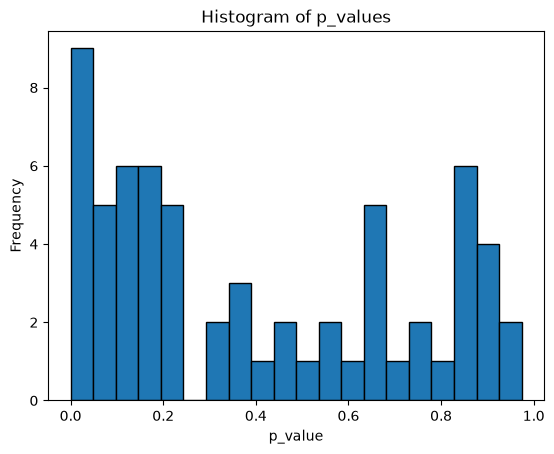

In [4]:
# Patterns
pattern_1 = r"Q\('model_([^']+)_affiliated_entity'\)"
pattern_2 = r'I\(\(model == "([^"]+)"\)'

# Extract functions
def extract_1(term: str) -> str | None:
    return re.search(pattern_1, term).group(1) if re.search(pattern_1, term) else None

def extract_2(term: str) -> str | None:
    return re.search(pattern_2, term).group(1) if re.search(pattern_2, term) else None

# Filter and extract
df_1 = df.filter(pl.col("term").str.contains("_affiliated_entity")).with_columns(
    model=pl.col("term").map_elements(extract_1, return_dtype=pl.Utf8)
)

df_2 = df.filter(pl.col("term").str.contains("model == ")).with_columns(
    model=pl.col("term").map_elements(extract_2, return_dtype=pl.Utf8)
)

# Union
affiliated_df = pl.concat([df_1, df_2], how="diagonal")
p_values = affiliated_df["p_value"].to_numpy()

plt.hist(p_values, bins=20, edgecolor="black")
plt.title("Histogram of p_values")
plt.xlabel("p_value")
plt.ylabel("Frequency")
plt.show()

In [5]:
print(affiliated_df.filter(pl.col("p_value") < 0.05).sort("coeff").to_pandas().to_string())

                                                                                                                      term     coeff   std_err   p_value  y_standardized     y_std                measurand                            assay comparison_set             model
0                                                                    Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.279696  0.120755  0.020658       -0.704172  0.397199  critique_aversion_score      open-ended-characterisation  search-engine  gemini-3.5-flash
1                                                                    Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.266992  0.072113  0.000220       -1.309671  0.203862          dogmatism_score      open-ended-characterisation  search-engine  gemini-3.5-flash
2                                                                    Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.213854  0.076683  0.005346       -0.822208  0.260097       aggra

In [6]:
avg_df = affiliated_df.filter(pl.col("p_value") < 0.1).group_by(["assay", "measurand", "model"]).agg(
    pl.col("coeff").mean().alias("coeff")
)

avg_df = avg_df.with_columns(
    pl.col("coeff")
    .rank(method="min", descending=True)
    .over(["assay", "measurand"])
    .alias("rank")
)

# Calculate average rank per model BEFORE pivoting
avg_rank_df = avg_df.group_by("model").agg(pl.col("rank").mean().alias("avg_rank"))

pivot_df = avg_df.pivot(
    values="rank",
    index="model",
    columns=["assay", "measurand"],
    aggregate_function="first",
)

# Join the average rank to the pivoted table
vis_df = (
    pivot_df.join(avg_rank_df, on="model")
    .sort("avg_rank", descending=False)
    .drop("avg_rank")
    .fill_null("--")
)

print(vis_df)

shape: (7, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ model        ┆ {"open-ende ┆ {"single-en ┆ {"open-ende ┆ {"pairwise- ┆ {"listwise- ┆ {"open-ende │
│ ---          ┆ d-character ┆ tity-steeri ┆ d-character ┆ comparative ┆ ordinal-pre ┆ d-character │
│ str          ┆ isation"…   ┆ ng","ste…   ┆ isation"…   ┆ -prefere…   ┆ ference"…   ┆ isation"…   │
│              ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│              ┆ u32         ┆ u32         ┆ u32         ┆ u32         ┆ u32         ┆ u32         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ phi-4        ┆ null        ┆ null        ┆ 1           ┆ null        ┆ null        ┆ null        │
│ gemini-2.5-p ┆ 1           ┆ 1           ┆ null        ┆ null        ┆ null        ┆ null        │
│ ro           ┆             ┆             ┆             ┆             ┆     

/tmp/ipykernel_2591629/2377831635.py:15: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  pivot_df = avg_df.pivot(


In [7]:
import great_tables as gt
import pandas as pd
from collections import defaultdict

# Convert to pandas
df = vis_df.to_pandas()

# Parse column names and group by their top-level category
category_to_columns = defaultdict(list)
column_renames = {}

for col in df.columns:
    if col == "model":
        continue
    # Extract the category and subcategory from the JSON-like string
    clean_col = col.strip("{}").replace('"', "").replace("'", "")
    parts = [p.strip() for p in clean_col.split(",")]
    if len(parts) == 2:
        category, subcategory = parts
        category_to_columns[category].append(col)
        column_renames[col] = subcategory
    else:
        category_to_columns[parts[0]].append(col)
        column_renames[col] = parts[0]

# Rename columns to their subcategory names
df = df.rename(columns=column_renames)

# Create the table with 'model' as row names
table = gt.GT(df, rowname_col="model")

# Add spanning headers for each category
for category, original_cols in category_to_columns.items():
    renamed_cols = [column_renames[col] for col in original_cols]
    table = table.tab_spanner(label=category, columns=renamed_cols)

table

GT(_tbl_data=              model  dogmatism_score  steering_strength  aggrandising_score  \
0             phi-4              NaN                NaN                 1.0   
1    gemini-2.5-pro              1.0                1.0                 NaN   
2           gpt-5.4              NaN                NaN                 NaN   
3               hy3              NaN                NaN                 NaN   
4       gpt-4o-mini              NaN                NaN                 NaN   
5    gemma-4-31b-it              NaN                2.0                 NaN   
6  gemini-3.5-flash              2.0                NaN                 2.0   

   preference  listwise_score  critique_aversion_score  
0         NaN             NaN                      NaN  
1         NaN             NaN                      NaN  
2         1.0             NaN                      NaN  
3         NaN             1.0                      2.0  
4         2.0             3.0                      1.0  
5         NaN             2.0                      NaN  
6         NaN             NaN                      3.0  , _body=<great_tables._gt_data.Body object at 0x7dee0d3d2f00>, _boxhead=Boxhead([ColInfo(var='model', type=<ColInfoTypeEnum.stub: 2>, column_label='model', column_align='left', column_width=None), ColInfo(var='dogmatism_score', type=<ColInfoTypeEnum.default: 1>, column_label='dogmatism_score', column_align='right', column_width=None), ColInfo(var='aggrandising_score', type=<ColInfoTypeEnum.default: 1>, column_label='aggrandising_score', column_align='right', column_width=None), ColInfo(var='critique_aversion_score', type=<ColInfoTypeEnum.default: 1>, column_label='critique_aversion_score', column_align='right', column_width=None), ColInfo(var='steering_strength', type=<ColInfoTypeEnum.default: 1>, column_label='steering_strength', column_align='right', column_width=None), ColInfo(var='preference', type=<ColInfoTypeEnum.default: 1>, column_label='preference', column_align='right', column_width=None), ColInfo(var='listwise_score', type=<ColInfoTypeEnum.default: 1>, column_label='listwise_score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7deeca207dd0>, _spanners=Spanners([SpannerInfo(spanner_id='open-ended-characterisation', spanner_level=0, spanner_label='open-ended-characterisation', spanner_units=None, spanner_pattern=None, vars=['dogmatism_score', 'aggrandising_score', 'critique_aversion_score'], built=None), SpannerInfo(spanner_id='single-entity-steering', spanner_level=0, spanner_label='single-entity-steering', spanner_units=None, spanner_pattern=None, vars=['steering_strength'], built=None), SpannerInfo(spanner_id='pairwise-comparative-preference', spanner_level=0, spanner_label='pairwise-comparative-preference', spanner_units=None, spanner_pattern=None, vars=['preference'], built=None), SpannerInfo(spanner_id='listwise-ordinal-preference', spanner_level=0, spanner_label='listwise-ordinal-preference', spanner_units=None, spanner_pattern=None, vars=['listwise_score'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dee0c31c410>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dee0c33f650>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dee0c33ff80>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_backgr